In [29]:
import numpy as np
import matplotlib.pyplot as plt
from langevin_samplers import (run_hmc,run_k_langevin,run_od_langevin, several_runs) 

In [ ]:
#anisotropic gaussian potential
def U_anipara(x):
    x1,x2 = x
    return 0.5*x1**2 + 0.5*4*x2**2

def gradU_anipara(x):
    x1,x2 = x
    return np.array([x1, 4*x2])

def empirical_cov(X):
    Xc = X - X.mean(axis=0, keepdims=True)
    return (Xc.T @ Xc) / X.shape[0]


In [31]:
def error_value(X_ensemble,cov_matrix):
    n, N, d = X_ensemble.shape
    errors = np.zeros((n, d))

    for i in range(n):
        X = X_ensemble[i, :, :]          # (N, d)
        cov_emp = empirical_cov(X)       # (d, d)
        errors[i, :] = np.abs(np.diag(cov_emp) - np.diag(cov_matrix))

    return np.max(errors)
    
    

In [63]:
target_cov = np.array([[1.0, 0.0],
                       [0.0, 0.25]])

x0 = np.array([1.0,1.0])
v0 = np.random.randn(2)
sampler = run_hmc
gradU = gradU_anipara
n = 50
N = 1000
delta = 0.1
eta = 0.0
K_list = np.arange(1,70)
errors = []

for K in K_list:
    X_ensemble, V_ensemble = several_runs(x0, v0,gradU,sampler,
        n=n,
        N=N,
        delta=delta,
        K=K,
        eta=eta
    )
    
    error = error_value(X_ensemble, target_cov)
    errors.append(error)
    print(f'K value: {K}, error: {error}')

    

K value: 1, error: 1.0403389282693078
K value: 2, error: 0.6466751801045675
K value: 3, error: 0.5308146501057536
K value: 4, error: 0.39419693227857444
K value: 5, error: 0.2364289493698547
K value: 6, error: 0.25869960436679384
K value: 7, error: 0.24895347829022763
K value: 8, error: 0.19336017834635155
K value: 9, error: 0.1959758445839992
K value: 10, error: 0.2162493516898525
K value: 11, error: 0.12935129774896126
K value: 12, error: 0.13280969788746577
K value: 13, error: 0.11300873718113114
K value: 14, error: 0.09754185839485663
K value: 15, error: 0.17171165874886357
K value: 16, error: 0.45447241880146483
K value: 17, error: 0.12929248396865445
K value: 18, error: 0.11355184407005137
K value: 19, error: 0.11498485980199735
K value: 20, error: 0.13970581832538165
K value: 21, error: 0.1145222850168297
K value: 22, error: 0.11097569374635763
K value: 23, error: 0.14821229869680952
K value: 24, error: 0.10517626358677323
K value: 25, error: 0.17054982988745482
K value: 26, err

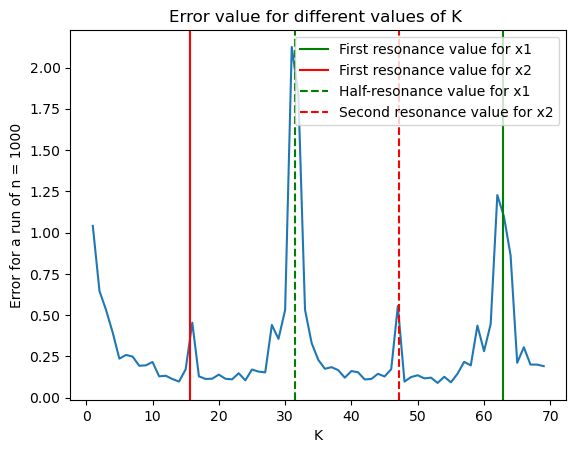

In [72]:
plt.plot(K_list[:69], errors)
plt.axvline((2*np.pi)/(0.1), label = 'First resonance value for x1', color='green')
plt.axvline((2*np.pi)/(4*0.1), label='First resonance value for x2', color = 'red')
plt.axvline((np.pi)/(0.1), label='Half-resonance value for x1', color = 'green', linestyle='--')
plt.axvline((6*np.pi)/(4*0.1), label='Second resonance value for x2', color = 'red', linestyle='--')


plt.ylabel('Error for a run of n = 1000')
plt.xlabel('K')
plt.title('Error value for different values of K ')
plt.legend()

A different approach is possible to visualize this phenomena: computing the MSD (mean-squared displacement), mathematically given by $\mathbb{E}[|x_{n+K} - x_n|^2]$. 

In [8]:
def msd_per_trajectory_from_verlet_path(X_ensemble, K):
    """
    X_ensemble: (n, Nsteps, d) where Nsteps is the number of STORED VERLET STEPS (+1 if includes initial).
    Returns E[ ||x_{tK} - x_{(t-1)K}||^2 ] averaged over runs and over trajectories.
    """
    n, Nsteps, d = X_ensemble.shape
    
    # take every K-th state (trajectory endpoints)
    X_end = X_ensemble[:, ::K, :]   # (n, Ntraj_end, d)
    
    # displacement between consecutive trajectory endpoints
    disp = X_end[:, 1:, :] - X_end[:, :-1, :]
    sq_norm = np.sum(disp**2, axis=2)
    return np.mean(sq_norm)

In [ ]:
x0 = np.array([1.0,1.0])
v0 = np.random.randn(2)
sampler = run_hmc
gradU = gradU_anipara
n = 50
N = 1000
delta = 0.1
eta = 0.0
K_list = np.arange(1,70)
errors = []

for K in K_list:
    X_ensemble, V_ensemble = several_runs(x0, v0,gradU,sampler,
        n=n,
        N=N,
        delta=delta,
        K=K,
        eta=eta
    )
    
    msd = msd_per_trajectory_from_verlet_path(X_ensemble, K)
    errors.append(msd)
    print(f'K value: {K}, msd: {msd}')

K value: 1, msd: 0.02039996528851092
K value: 2, msd: 0.03980424444901587
K value: 3, msd: 0.09884377929500338
K value: 4, msd: 0.19316607795488108
K value: 5, msd: 0.31511320682661076
K value: 6, msd: 0.46349626882590406
K value: 7, msd: 0.6318477266215557
K value: 8, msd: 0.8079356753906365
K value: 9, msd: 1.0002951735441488
K value: 10, msd: 3.0237158220368356
K value: 11, msd: 1.3376275719609187
K value: 12, msd: 1.481500811253341
K value: 13, msd: 1.6360201668887049
K value: 14, msd: 1.787993186629238
K value: 15, msd: 1.922386752557186
K value: 16, msd: 2.0466800146800104
K value: 17, msd: 2.2099829984220714
K value: 18, msd: 2.3263932688866307
K value: 19, msd: 2.477545912383384
K value: 20, msd: 2.655872324349558
K value: 21, msd: 2.8079906364516773
K value: 22, msd: 2.9975591997807425
K value: 23, msd: 3.249343432288238
K value: 24, msd: 3.3685698610177846
K value: 25, msd: 3.579470685971719
K value: 26, msd: 3.8412285260143686
K value: 27, msd: 3.926678058016897
K value: 28,

Text(0.5, 1.0, 'MSD for different values of K ')

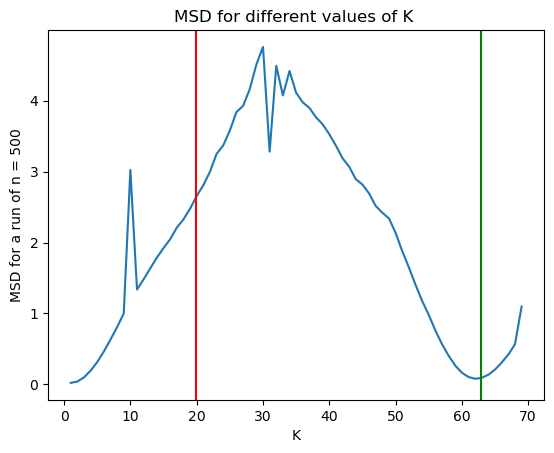

In [11]:
plt.plot(K_list[:69], errors)
plt.axvline((2*np.pi)/(np.sqrt(10)*0.1), label='Resonance value for x2', color = 'red')
plt.axvline((2*np.pi)/(0.1), label = 'Resonance value for x1', color='green')

plt.ylabel('MSD for a run of n = 500')
plt.xlabel('K')
plt.title('MSD for different values of K ')